<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/ml_projects/experiment_personal_finance_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving laramee26openBankTransactionData.xlsx to laramee26openBankTransactionData.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("laramee26openBankTransactionData.xlsx")
df.head()

,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country
0,1,25/07/2022,BP,SAVE THE CHANGE,3.11,NaN,541.43,Savings,Nottingham,UK
1,2,25/07/2022,DEB,LIDL GB NOTTINGHA,15.02,NaN,544.54,Groceries,Nottingham,UK
2,3,25/07/2022,DEB,NON-GBP PURCH FEE,0.50,NaN,559.56,Others,Nottingham,UK
3,4,25/07/2022,DEB,NON-GBP TRANS FEE,0.37,NaN,560.06,Others,Nottingham,UK
4,5,25/07/2022,DEB,TRAVELIUM LLC,12.59,NaN,560.43,NaN,NaN,NaN


## 1. Dynamic Data Pipelines: Automated Data Cleaning

In [3]:
# Display DataFrame information to check data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction Number       6567 non-null   int64  
 1   Transaction Date         6567 non-null   object 
 2   Transaction Type         6506 non-null   object 
 3   Transaction Description  6567 non-null   object 
 4   Debit Amount             6122 non-null   float64
 5   Credit Amount            445 non-null    float64
 6   Balance                  6567 non-null   float64
 7   Category                 6543 non-null   object 
 8   Location City            5895 non-null   object 
 9   Location Country         5881 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 513.2+ KB


None

In [4]:
# Convert 'Transaction Date' to datetime objects
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%d/%m/%Y')

# Display the updated DataFrame info to confirm the change
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Transaction Number       6567 non-null   int64         
 1   Transaction Date         6567 non-null   datetime64[ns]
 2   Transaction Type         6506 non-null   object        
 3   Transaction Description  6567 non-null   object        
 4   Debit Amount             6122 non-null   float64       
 5   Credit Amount            445 non-null    float64       
 6   Balance                  6567 non-null   float64       
 7   Category                 6543 non-null   object        
 8   Location City            5895 non-null   object        
 9   Location Country         5881 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 513.2+ KB


None

In [5]:
# Fill NaN values in 'Category' and 'Transaction Description' with empty strings
df['Category'] = df['Category'].fillna('')
df['Transaction Description'] = df['Transaction Description'].fillna('')

# Display unique values of 'Category' to understand the variety
print("Unique Categories before standardization:")
print(df['Category'].unique())

# Display a sample of 'Transaction Description' to understand its structure
print("\nSample of Transaction Descriptions:")
print(df['Transaction Description'].sample(10).tolist())

Unique Categories before standardization:
['Savings' 'Groceries' 'Others' '' 'Entertainment' 'Services' 'Amazon'
 'Investment' 'Supplementary Income' 'Dine Out' 'Travel' 'Bills'
 'Other Shopping' 'Cash' 'Home Improvement' 'Hotels'
 'Travel Reimbursement' 'Safety Deposit Return' 'Interest' 'Fitness'
 'Paycheck' 'Food Shopping' 'Clothes' 'Services/Home Improvement'
 'Account transfer' 'Mortgage' 'Insurance' 'Rent' 'Purchase of uk.eg.org'
 'Groceries ' 'Health']

Sample of Transaction Descriptions:
['MARKS&SPENCER PLC', 'SAVE THE CHANGE', 'SAVE THE CHANGE', 'Q WANG', 'SAVE THE CHANGE', 'TRAINAWAY APS', 'AMZNMktplace', 'SAVE THE CHANGE', 'SAVE THE CHANGE', 'ALADDINS BIKES']


In [6]:
def standardize_category(category):
    category = str(category).lower().strip()
    if 'grocer' in category or 'supermarket' in category:
        return 'Groceries'
    elif 'travel' in category or 'transport' in category or 'bus' in category or 'train' in category or 'flight' in category:
        return 'Travel & Transport'
    elif 'utilit' in category or 'electric' in category or 'water' in category or 'gas' in category or 'internet' in category:
        return 'Utilities'
    elif 'eat' in category or 'restaurant' in category or 'cafe' in category or 'food' in category:
        return 'Dining Out'
    elif 'shop' in category or 'retail' in category:
        return 'Shopping'
    elif 'health' in category or 'medical' in category or 'pharmacy' in category:
        return 'Health & Medical'
    elif 'salary' in category or 'income' in category or 'pay' in category:
        return 'Income'
    elif 'rent' in category or 'mortgage' in category:
        return 'Housing'
    elif 'entert' in category or 'movie' in category or 'music' in category or 'game' in category:
        return 'Entertainment'
    elif 'education' in category or 'course' in category or 'school' in category:
        return 'Education'
    elif 'fee' in category or 'charge' in category or 'other' in category or category == '':
        return 'Miscellaneous'
    else:
        return category.capitalize()

df['Category'] = df['Category'].apply(standardize_category)

print("Unique Categories after standardization:")
print(df['Category'].unique())

Unique Categories after standardization:
['Savings' 'Groceries' 'Miscellaneous' 'Entertainment' 'Services' 'Amazon'
 'Investment' 'Income' 'Dine out' 'Travel & Transport' 'Bills' 'Shopping'
 'Cash' 'Home improvement' 'Hotels' 'Safety deposit return' 'Interest'
 'Fitness' 'Dining Out' 'Clothes' 'Services/home improvement'
 'Account transfer' 'Housing' 'Insurance' 'Purchase of uk.eg.org'
 'Health & Medical']


In [9]:
import re

def extract_merchant_name(description):
    description = str(description).upper()

    # More specific patterns for known merchants (expanded)
    patterns = {
        r'AMZNMKTPLACE|AMZN MKTP|AMAZON': 'Amazon',
        r'LIDL GB': 'Lidl',
        r'MARKS&SPENCER PLC|M&S': 'Marks & Spencer',
        r'TRAINAWAY APS': 'Trainaway',
        r'TRAVELIUM LLC': 'Travelium',
        r'ALADDINS BIKES': 'Aladdins Bikes',
        r'Q WANG': 'Q Wang',
        r'UBER\s+\*?TRIP|UBER EATS': 'Uber',
        r'EXPEDIA': 'Expedia',
        r'SEVERN TRENT WATER': 'Severn Trent Water',
        r'GOOD ENERGY LTD': 'Good Energy',
        r'HEAVENLY DESSERTS': 'Heavenly Desserts',
        r'RLR-CC\.COM': 'RLR-CC',
        r'TESCO': 'Tesco',
        r'SAINSBURYS': 'Sainsbury\'s',
        r'ASDA': 'Asda',
        r'PAYPAL': 'PayPal',
        r'GOOGLE': 'Google',
        r'APPLE': 'Apple',
        r'SPOTIFY': 'Spotify',
        r'NETFLIX': 'Netflix',
        r'CO-OP': 'Co-op',
        r'STARBUCKS': 'Starbucks',
        r'COSTA': 'Costa',
        r'SPORTSDIRECT': 'Sports Direct',
        r'CORGI HOMEPLAN': 'Corgi HomePlan',
        r'ARRIVA TRAINS': 'Arriva Trains',
        r'B&Q': 'B&Q',
        r'PRIMARK': 'Primark',
        r'HMV': 'HMV',
        r'NATWEST': 'NatWest',
        r'LLOYDS BANK': 'Lloyds Bank',
        r'BARCLAYS': 'Barclays',
        r'HALIFAX': 'Halifax'
    }

    for pattern, merchant_name in patterns.items():
        if re.search(pattern, description):
            return merchant_name

    # Handle specific common phrases that are not merchants
    if 'SAVE THE CHANGE' in description:
        return 'Savings Transfer'
    if 'NON-GBP' in description:
        return 'Foreign Transaction Fee'
    if 'ACCOUNT FEE' in description or 'BANK CHARGE' in description:
        return 'Bank Fees'
    if 'CC SWANSEA C.TAX' in description or 'COUNCIL TAX' in description:
        return 'Council Tax'
    if 'ANDREW MUMBI' in description or 'PAULINA PIPPEN' in description or re.search(r'P2P|PERSON TO PERSON', description):
        return 'Personal Transfer'

    # Improved general extraction for remaining descriptions
    # This pattern tries to capture the first significant word(s) that look like a merchant name
    # and excludes common noise words or transaction identifiers.
    # Adjusted to be more selective, focusing on capitalized words at the beginning.
    match = re.search(r'^([A-Z][A-Z0-9\s&\.-]+?)(?:\s+GB|\s+LLC|\s+APS|\s+PLC|\s+LTD|\s+CO|\s+INC|\s+CORP|\s+STORE|\s+SUPERMARKET|\s+CAFE|\s+REST|\s+PUB|\s+GRAB|\s+EBAY|\s+PRIME|\s+SUBSCRIPTION|\s+SERVICES|\s+ONLINE|\s+SHOP|\s+ECOM|\s+MARKET|\s+CITY|\s+UK|\s+US|\s+EU|\s+\d{2}/\d{2}|\s+\d{1,4})', description)
    if match:
        potential_merchant = match.group(1).strip()
        # Filter out common non-merchant phrases or single words that are not merchants
        exclusion_list = [
            'TRANSFER', 'PAYMENT', 'INCOME', 'FEE', 'INTEREST', 'DEBIT', 'CREDIT', 'BILL',
            'CHARGE', 'TOP UP', 'REFUND', 'BANK', 'TRANSACTION', 'FX', 'WITHDRAWAL', 'DEPOSIT',
            'CARD', 'AUTH', 'PURCHASE', 'SALE', 'SERVICE', 'ADJUSTMENT', 'CASH'
        ]
        if len(potential_merchant) > 2 and not any(phrase in potential_merchant for phrase in exclusion_list):
            return ' '.join([word.capitalize() for word in potential_merchant.split()])

    return 'Unknown Merchant'

df['Merchant Name'] = df['Transaction Description'].apply(extract_merchant_name)

# Display a sample of transaction descriptions and their extracted merchant names
print("\nSample of Transaction Description and Extracted Merchant Name after further refinement:")
display(df[['Transaction Description', 'Merchant Name']].sample(10))


Sample of Transaction Description and Extracted Merchant Name after further refinement:


,Transaction Description,Merchant Name
452,PRIMARK,Primark
3041,AMZNMKTPLACE AMAZO,Amazon
1614,AMAZON.CO.UK*MK74Z,Amazon
293,STARBUCKS,Starbucks
1326,AMZNMktplace,Amazon
709,MISS D WU,Unknown Merchant
1272,Amazon.co.uk*VM9GG,Amazon
1890,SAINSBURYS S/MKT,Sainsbury's
6145,Amazon UK Marketpl,Amazon
20,UBER *TRIP,Uber


## Dual-Grain Timelines: Daily and Monthly Aggregations

In [10]:
# Calculate daily debit and credit amounts
daily_transactions = df.groupby('Transaction Date').agg(
    Daily_Debit=('Debit Amount', 'sum'),
    Daily_Credit=('Credit Amount', 'sum')
).fillna(0)

# Calculate daily net flow
daily_transactions['Daily_Net_Flow'] = daily_transactions['Daily_Credit'] - daily_transactions['Daily_Debit']

# Display the first few rows of the daily transactions dataframe
print("\nDaily Transaction Summary:")
display(daily_transactions.head())


Daily Transaction Summary:


,Daily_Debit,Daily_Credit,Daily_Net_Flow
Transaction Date,,,
2015-01-09,1767.78,4.74,-1763.04
2015-01-10,1296.19,4.90,-1291.29
2015-01-12,1353.31,4.74,-1348.57
2015-02-09,131.08,0.00,-131.08
2015-02-10,1112.02,0.00,-1112.02


In [11]:
# Extract year and month for monthly aggregation
df['YearMonth'] = df['Transaction Date'].dt.to_period('M')

# Calculate monthly debit and credit amounts
monthly_transactions = df.groupby('YearMonth').agg(
    Monthly_Debit=('Debit Amount', 'sum'),
    Monthly_Credit=('Credit Amount', 'sum')
).fillna(0)

# Calculate monthly net flow
monthly_transactions['Monthly_Net_Flow'] = monthly_transactions['Monthly_Credit'] - monthly_transactions['Monthly_Debit']

# Convert YearMonth to string for better display if needed, or reset index
monthly_transactions = monthly_transactions.reset_index()
monthly_transactions['YearMonth'] = monthly_transactions['YearMonth'].astype(str)

# Display the first few rows of the monthly transactions dataframe
print("\nMonthly Transaction Summary:")
display(monthly_transactions.head())


Monthly Transaction Summary:


,YearMonth,Monthly_Debit,Monthly_Credit,Monthly_Net_Flow
0,2015-01,4417.28,14.38,-4402.90
1,2015-02,2402.46,5.23,-2397.23
2,2015-03,3283.41,590.69,-2692.72
3,2015-04,288.13,0.00,-288.13
4,2015-05,155.74,0.00,-155.74


## Multi-Currency Tracking

In [12]:
# Check unique values in 'Location Country' to determine if multi-currency tracking is needed
print("Unique countries in the dataset:")
print(df['Location Country'].unique())

# Also check if there are any non-GBP transactions explicitly mentioned in description (though less reliable)
print("\nTransactions mentioning 'NON-GBP':")
display(df[df['Transaction Description'].str.contains('NON-GBP', case=False, na=False)].head())

Unique countries in the dataset:
['UK' nan 'Italy' 'Canada' 'Spain' 'Denmark' 'Netherlands' 'USA'
 'Portugal' 'France' 'Germany' 'Moldova' 'Greece' 'Czech Republic'
 'Prague' 'Hungary' 'Morocco']

Transactions mentioning 'NON-GBP':


,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country,Merchant Name,YearMonth
2,3,2022-07-25,DEB,NON-GBP PURCH FEE,0.50,NaN,559.56,Miscellaneous,Nottingham,UK,Foreign Transaction Fee,2022-07
3,4,2022-07-25,DEB,NON-GBP TRANS FEE,0.37,NaN,560.06,Miscellaneous,Nottingham,UK,Foreign Transaction Fee,2022-07
107,108,2022-06-21,DEB,NON-GBP TRANS FEE,0.06,NaN,777.18,Miscellaneous,Nottingham,UK,Foreign Transaction Fee,2022-06
115,116,2022-06-20,DEB,NON-GBP TRANS FEE,0.44,NaN,647.20,Miscellaneous,Nottingham,UK,Foreign Transaction Fee,2022-06
118,119,2022-06-20,DEB,NON-GBP TRANS FEE,0.57,NaN,664.24,Miscellaneous,Nottingham,UK,Foreign Transaction Fee,2022-06


In [13]:
# Fill NaN values in 'Location Country' - assuming UK for unstated locations as a default
df['Location Country'] = df['Location Country'].fillna('UK')

# Define a simple exchange rate for demonstration (e.g., 1 Foreign Currency Unit = 0.8 GBP)
EXCHANGE_RATE_FOREIGN_TO_GBP = 0.8

def convert_to_gbp(row):
    if row['Location Country'] != 'UK':
        # Assuming Debit Amount and Credit Amount are in the foreign currency for non-UK transactions
        if pd.notna(row['Debit Amount']):
            row['Debit Amount (GBP)'] = row['Debit Amount'] * EXCHANGE_RATE_FOREIGN_TO_GBP
        else:
            row['Debit Amount (GBP)'] = None
        if pd.notna(row['Credit Amount']):
            row['Credit Amount (GBP)'] = row['Credit Amount'] * EXCHANGE_RATE_FOREIGN_TO_GBP
        else:
            row['Credit Amount (GBP)'] = None
    else:
        row['Debit Amount (GBP)'] = row['Debit Amount']
        row['Credit Amount (GBP)'] = row['Credit Amount']
    return row

# Apply the conversion function
df = df.apply(convert_to_gbp, axis=1)

# Display a sample of transactions showing original and converted amounts for non-UK transactions
print("\nSample of transactions with currency conversion (non-UK):")
display(df[df['Location Country'] != 'UK'][['Transaction Description', 'Location Country', 'Debit Amount', 'Credit Amount', 'Debit Amount (GBP)', 'Credit Amount (GBP)']].sample(5))


Sample of transactions with currency conversion (non-UK):


,Transaction Description,Location Country,Debit Amount,Credit Amount,Debit Amount (GBP),Credit Amount (GBP)
5100,GRUPO HOTELES PLAY,Spain,607.58,NaN,486.064,NaN
4265,CD BRNO HL.N.,Czech Republic,7.51,NaN,6.008,NaN
137,EAST MIDS RAILWAY,Italy,56.70,NaN,45.360,NaN
3203,AMISTATISLANDHOSTE,Spain,54.72,NaN,43.776,NaN
4899,HYATT REGENCY PHOE,USA,179.44,NaN,143.552,NaN


## 2. Interactive Visual Analytics: Sunburst Category Hierarchies

In [14]:
# Calculate total debit amount for each category and merchant
category_merchant_spending = df.groupby(['Category', 'Merchant Name'])['Debit Amount (GBP)'].sum().reset_index()

# Filter out 'Income' and 'Savings Transfer' to focus on expenses
category_merchant_spending = category_merchant_spending[~category_merchant_spending['Category'].isin(['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax'])]

# Rename columns for clarity in Plotly
category_merchant_spending.columns = ['Category', 'Subcategory', 'Amount']

# Display the top few rows of the aggregated data
print("\nAggregated Spending by Category and Merchant:")
display(category_merchant_spending.sort_values(by='Amount', ascending=False).head(10))


Aggregated Spending by Category and Merchant:


,Category,Subcategory,Amount
126,Investment,Unknown Merchant,128611.94
0,Account transfer,Unknown Merchant,84000.00
97,Housing,Unknown Merchant,31364.35
148,Savings,Unknown Merchant,25600.00
152,Services,Unknown Merchant,23504.31
1,Amazon,Amazon,21172.45
4,Bills,Barclays,19658.44
96,Housing,NatWest,19562.32
21,Cash,Unknown Merchant,18136.86
93,Home improvement,Unknown Merchant,16114.83


In [30]:
import plotly.graph_objects as go
import pandas as pd

# Prepare data explicitly for Sunburst chart
sunburst_data_list = []

# Add entries for categories (top level nodes)
category_total_spending = category_merchant_spending.groupby('Category')['Amount'].sum().reset_index()
for index, row in category_total_spending.iterrows():
    sunburst_data_list.append({
        'ids': row['Category'],
        'labels': row['Category'],
        'parents': '', # Root node has an empty string as parent
        'values': row['Amount']
    })

# Add entries for merchant names (second level nodes)
for index, row in category_merchant_spending.iterrows():
    sunburst_data_list.append({
        'ids': f"{row['Category']}-{row['Subcategory']}", # Create a unique ID for each merchant within its category
        'labels': row['Subcategory'],
        'parents': row['Category'],
        'values': row['Amount']
    })

sunburst_df = pd.DataFrame(sunburst_data_list)

# Create the Sunburst chart with explicit ids, labels, parents, and values
fig = go.Figure(go.Sunburst(
    ids=sunburst_df['ids'],
    labels=sunburst_df['labels'],
    parents=sunburst_df['parents'],
    values=sunburst_df['values'],
    branchvalues="total", # This should now correctly sum up values for parent nodes
    hovertemplate='<b>%{label}</b><br>Amount: £%{value:.2f}<extra></extra>'
))

fig.update_layout(margin = dict(t=0, l=0, r=0, b=0),
                  title_text='Spending Categories Hierarchy (Sunburst Chart)',
                  title_x=0.5)

fig.show()

## Dual-Axis Tracking: Monthly Spending vs. Income Trends

In [18]:
# Calculate monthly spending for each category
monthly_category_spending = df.groupby(['YearMonth', 'Category'])['Debit Amount (GBP)'].sum().unstack(fill_value=0).reset_index()

# Calculate monthly income
monthly_income = df[df['Category'] == 'Income'].groupby('YearMonth')['Credit Amount (GBP)'].sum().reset_index()
monthly_income.rename(columns={'Credit Amount (GBP)': 'Monthly Income'}, inplace=True)

# Merge monthly spending and income data
monthly_financials = pd.merge(monthly_category_spending, monthly_income, on='YearMonth', how='left').fillna(0)

# Convert 'YearMonth' back to datetime for plotting
monthly_financials['YearMonth'] = monthly_financials['YearMonth'].dt.to_timestamp()

# Display the first few rows of the prepared data
print("\nMonthly Financial Summary for Dual-Axis Chart:")
display(monthly_financials.head())


Monthly Financial Summary for Dual-Axis Chart:


,YearMonth,Account transfer,Amazon,Bills,Cash,Clothes,Dine out,Dining Out,Entertainment,Fitness,...,Investment,Miscellaneous,Purchase of uk.eg.org,Safety deposit return,Savings,Services,Services/home improvement,Shopping,Travel & Transport,Monthly Income
0,2015-01-01,0.0,46.84,643.77,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,903.96,0.0,0.0,0.0,497.96,0.00
1,2015-02-01,0.0,113.05,92.57,50.0,0.0,0.0,0.0,0.0,0.0,...,0.0,65.37,0.0,0.0,303.34,0.0,0.0,0.0,0.00,0.00
2,2015-03-01,0.0,179.44,280.57,425.0,0.0,0.0,0.0,0.0,0.0,...,0.0,28.20,0.0,0.0,303.44,0.0,0.0,0.0,0.00,585.29
3,2015-04-01,0.0,39.37,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,2.20,0.0,0.0,0.0,94.00,0.00
4,2015-05-01,0.0,94.29,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,4.89,0.0,0.0,0.0,0.00,0.00


In [19]:
# Re-executing the cell after modification
# Calculate monthly spending for each category
monthly_category_spending = df.groupby(['YearMonth', 'Category'])['Debit Amount (GBP)'].sum().unstack(fill_value=0).reset_index()

# Calculate monthly income
monthly_income = df[df['Category'] == 'Income'].groupby('YearMonth')['Credit Amount (GBP)'].sum().reset_index()
monthly_income.rename(columns={'Credit Amount (GBP)': 'Monthly Income'}, inplace=True)

# Merge monthly spending and income data
monthly_financials = pd.merge(monthly_category_spending, monthly_income, on='YearMonth', how='left').fillna(0)

# Convert 'YearMonth' back to datetime for plotting
monthly_financials['YearMonth'] = monthly_financials['YearMonth'].dt.to_timestamp()

# Display the first few rows of the prepared data
print("\nMonthly Financial Summary for Dual-Axis Chart:")
display(monthly_financials.head())


Monthly Financial Summary for Dual-Axis Chart:


,YearMonth,Account transfer,Amazon,Bills,Cash,Clothes,Dine out,Dining Out,Entertainment,Fitness,...,Investment,Miscellaneous,Purchase of uk.eg.org,Safety deposit return,Savings,Services,Services/home improvement,Shopping,Travel & Transport,Monthly Income
0,2015-01-01,0.0,46.84,643.77,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,903.96,0.0,0.0,0.0,497.96,0.00
1,2015-02-01,0.0,113.05,92.57,50.0,0.0,0.0,0.0,0.0,0.0,...,0.0,65.37,0.0,0.0,303.34,0.0,0.0,0.0,0.00,0.00
2,2015-03-01,0.0,179.44,280.57,425.0,0.0,0.0,0.0,0.0,0.0,...,0.0,28.20,0.0,0.0,303.44,0.0,0.0,0.0,0.00,585.29
3,2015-04-01,0.0,39.37,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,2.20,0.0,0.0,0.0,94.00,0.00
4,2015-05-01,0.0,94.29,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,4.89,0.0,0.0,0.0,0.00,0.00


In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Prepare data for plotting (excluding non-expense categories from spending sum for a clearer view)
expense_categories = [col for col in monthly_financials.columns if col not in ['YearMonth', 'Monthly Income'] and col not in ['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax']]
monthly_financials['Total Monthly Spending'] = monthly_financials[expense_categories].sum(axis=1)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces for individual category spending (bars)
for category in expense_categories:
    fig.add_trace(
        go.Bar(
            x=monthly_financials['YearMonth'],
            y=monthly_financials[category],
            name=category,
            hovertemplate='<b>%{x|%Y-%m}</b><br>' + category + ': £%{y:.2f}<extra></extra>'
        ),
        secondary_y=False,
    )

# Add trace for total monthly income (line)
fig.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Monthly Income'],
        name='Monthly Income',
        mode='lines+markers',
        line=dict(color='green', width=3),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Monthly Income: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)

# Add trace for total monthly spending (line) for trend comparison
fig.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Total Monthly Spending'],
        name='Total Monthly Spending',
        mode='lines+markers',
        line=dict(color='red', width=3, dash='dash'),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Total Monthly Spending: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)

# Update layout
fig.update_layout(
    title_text="Monthly Categorical Spending vs. Income and Total Spending Trends",
    title_x=0.5,
    barmode='stack',
    hovermode="x unified",
    xaxis_title="Date",
    yaxis_title="Monthly Spending (GBP)",
    legend_title="Category",
    height=800 # Increased height
)
fig.update_yaxes(title_text="Monthly Income / Total Spending (GBP)", secondary_y=True)

fig.show()

## 3. Intelligent Financial Modeling: AI Spending Forecasts

Mean Squared Error for Spending Forecast: 16753237.04


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



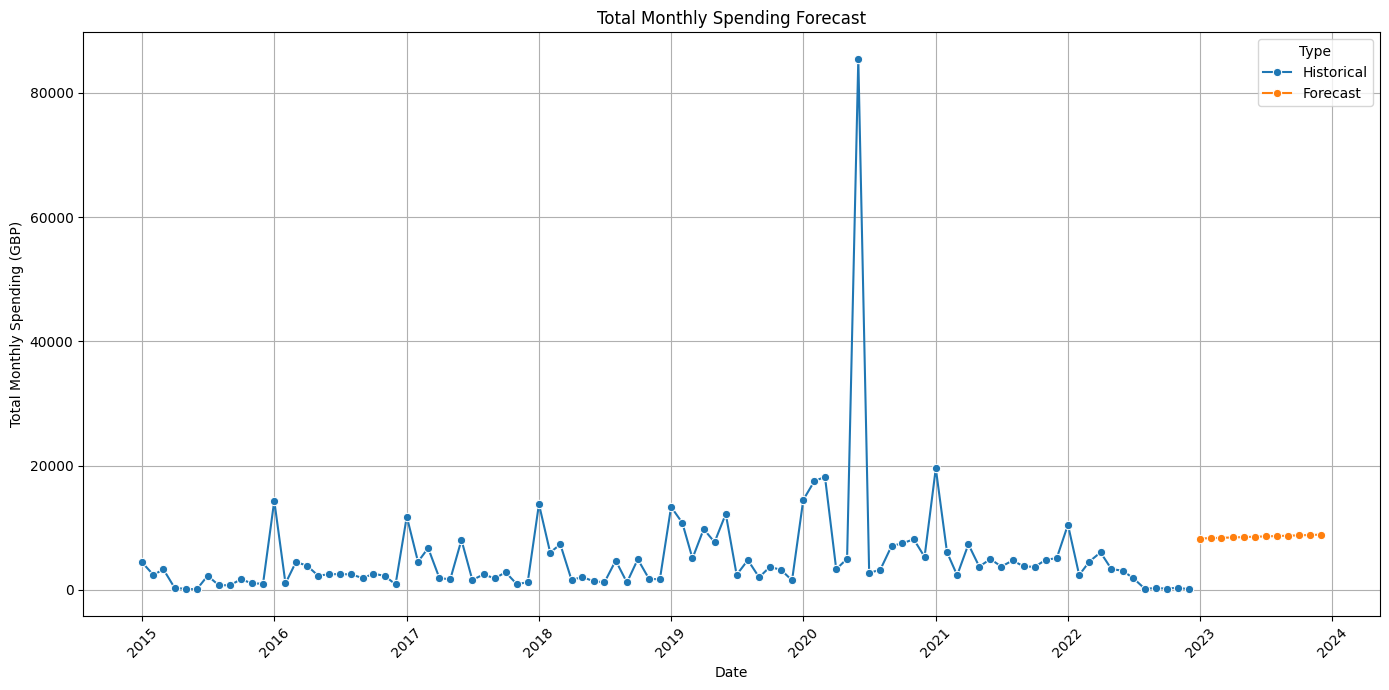

In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for forecasting
# We'll forecast 'Total Monthly Spending'
forecast_df = monthly_financials[['YearMonth', 'Total Monthly Spending']].copy()

# Convert YearMonth to a numerical representation (e.g., months since start)
forecast_df['Months_Since_Start'] = (forecast_df['YearMonth'] - forecast_df['YearMonth'].min()).dt.days / 30.44

# Prepare features (X) and target (y)
X = forecast_df[['Months_Since_Start']]
y = forecast_df['Total Monthly Spending']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error for Spending Forecast: {mse:.2f}")

# Generate future months for forecasting
last_month_num = X['Months_Since_Start'].max()
future_months_num = np.arange(last_month_num + 1, last_month_num + 1 + 12).reshape(-1, 1) # Forecast 12 months into the future
future_predictions = model.predict(future_months_num)

# Create future YearMonth dates
last_date = forecast_df['YearMonth'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Combine historical and forecasted data for plotting
historical_data = forecast_df.copy()
historical_data.rename(columns={'Total Monthly Spending': 'Spending'}, inplace=True)
historical_data['Type'] = 'Historical'

forecast_data = pd.DataFrame({
    'YearMonth': future_dates,
    'Spending': future_predictions,
    'Type': 'Forecast'
})

combined_data = pd.concat([historical_data[['YearMonth', 'Spending', 'Type']], forecast_data])

# Plotting the forecast
plt.figure(figsize=(14, 7))
sns.lineplot(data=combined_data, x='YearMonth', y='Spending', hue='Type', marker='o')
plt.title('Total Monthly Spending Forecast')
plt.xlabel('Date')
plt.ylabel('Total Monthly Spending (GBP)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Intelligent Financial Modeling: Algorithmic Budget Audits (e.g., 50/30/20 Rule)

In [32]:
# The 50/30/20 rule suggests: 50% Needs, 30% Wants, 20% Savings/Debt Repayment.
# We'll need to map our categories to these buckets.

# Define categories for Needs, Wants, and Savings based on our standardized categories
# This is a simplification and might need user input for more accuracy in a real application
needs_categories = [
    'Groceries', 'Housing', 'Utilities', 'Health & Medical',
    'Travel & Transport', 'Bills', 'Services'
]
wants_categories = [
    'Dining Out', 'Entertainment', 'Shopping', 'Amazon',
    'Fitness', 'Home improvement', 'Hotels', 'Dine out', 'Clothes'
]
savings_categories = [
    'Savings', 'Investment', 'Account transfer'
]

# Ensure monthly_transactions 'YearMonth' is datetime for merging
monthly_transactions['YearMonth'] = pd.to_datetime(monthly_transactions['YearMonth'].astype(str))

# Merge total monthly credits into monthly_financials from monthly_transactions
# This adds a 'Monthly_Credit' column to monthly_financials, which represents all credits for that month
monthly_financials = pd.merge(monthly_financials, monthly_transactions[['YearMonth', 'Monthly_Credit']], on='YearMonth', how='left').fillna(0)

# Calculate monthly total income
# If 'Monthly Income' (from 'Income' category) is 0, use 'Monthly_Credit' (total credits) as a fallback
monthly_financials['Actual Monthly Income'] = monthly_financials.apply(
    lambda row: row['Monthly_Credit'] if row['Monthly Income'] == 0 else row['Monthly Income'],
    axis=1
)

# Replace any remaining NaN (should be handled by fillna(0) but good to be safe) with 0
monthly_financials['Actual Monthly Income'] = monthly_financials['Actual Monthly Income'].replace(np.nan, 0)

# Calculate spending in each bucket for each month
monthly_financials['Needs_Spending'] = monthly_financials[[
    col for col in needs_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Wants_Spending'] = monthly_financials[[
    col for col in wants_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Savings_Spending'] = monthly_financials[[
    col for col in savings_categories if col in monthly_financials.columns
]].sum(axis=1)

# Calculate percentage of income for each bucket
# Handle division by zero by replacing 0 with NaN before division, then fill NaN with 0
monthly_financials['Needs_%'] = (monthly_financials['Needs_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Wants_%'] = (monthly_financials['Wants_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Savings_%'] = (monthly_financials['Savings_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)

# Replace infinite values (from division by zero income) with 0 or handle them as appropriate
monthly_financials.replace([np.inf, -np.inf], 0, inplace=True)

# Display the audit for a sample month or the overall average
print("\n50/30/20 Budget Audit (Averages across all months with income > 0):")

average_income_months = monthly_financials[monthly_financials['Actual Monthly Income'] > 0]

if not average_income_months.empty:
    avg_needs_percent = average_income_months['Needs_%'].mean()
    avg_wants_percent = average_income_months['Wants_%'].mean()
    avg_savings_percent = average_income_months['Savings_%'].mean()

    print(f"Average Needs Spending: {avg_needs_percent:.2f}% (Target: 50%)")
    print(f"Average Wants Spending: {avg_wants_percent:.2f}% (Target: 30%)")
    print(f"Average Savings/Debt Spending: {avg_savings_percent:.2f}% (Target: 20%)")

    # Visualize the 50/30/20 breakdown for months with income
    audit_data = average_income_months[['YearMonth', 'Needs_%', 'Wants_%', 'Savings_%']].melt(id_vars='YearMonth', var_name='Category Type', value_name='Percentage of Income')
    audit_data['Target'] = audit_data['Category Type'].map({'Needs_%': 50, 'Wants_%': 30, 'Savings_%': 20})

    fig = px.bar(
        audit_data,
        x='YearMonth',
        y='Percentage of Income',
        color='Category Type',
        title='Monthly 50/30/20 Budget Rule Adherence',
        labels={'Percentage of Income': 'Percentage of Income', 'YearMonth': 'Month'},
        hover_data={'Target': ':.0f'}
    )
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[50]*len(audit_data['YearMonth'].unique()), mode='lines', name='Needs Target (50%)', line=dict(color='red', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[30]*len(audit_data['YearMonth'].unique()), mode='lines', name='Wants Target (30%)', line=dict(color='orange', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[20]*len(audit_data['YearMonth'].unique()), mode='lines', name='Savings Target (20%)', line=dict(color='green', dash='dash')))

    fig.update_layout(barmode='relative', yaxis_range=[0, 100])
    fig.show()
else:
    print("No months with income found to perform budget audit.")


50/30/20 Budget Audit (Averages across all months with income > 0):
Average Needs Spending: 702.87% (Target: 50%)
Average Wants Spending: 56.17% (Target: 30%)
Average Savings/Debt Spending: 167.82% (Target: 20%)


## Intelligent Financial Modeling: Algorithmic Budget Audits (e.g., 50/30/20 Rule)

In [35]:
# The 50/30/20 rule suggests: 50% Needs, 30% Wants, 20% Savings/Debt Repayment.
# We'll need to map our categories to these buckets.

# Define categories for Needs, Wants, and Savings based on our standardized categories
# This is a simplification and might need user input for more accuracy in a real application
needs_categories = [
    'Groceries', 'Housing', 'Utilities', 'Health & Medical',
    'Travel & Transport', 'Bills', 'Services'
]
wants_categories = [
    'Dining Out', 'Entertainment', 'Shopping', 'Amazon',
    'Fitness', 'Home improvement', 'Hotels', 'Dine out', 'Clothes'
]
savings_categories = [
    'Savings', 'Investment', 'Account transfer'
]

# Ensure monthly_transactions 'YearMonth' is datetime for merging
# monthly_transactions['YearMonth'] is a string, convert it to datetime for merging
monthly_transactions['YearMonth'] = pd.to_datetime(monthly_transactions['YearMonth'])

# Before merging, check if 'Monthly_Credit' exists in monthly_financials and drop it if it does
if 'Monthly_Credit' in monthly_financials.columns:
    monthly_financials = monthly_financials.drop(columns=['Monthly_Credit'])

# Merge total monthly credits into monthly_financials from monthly_transactions
# This adds a 'Monthly_Credit' column to monthly_financials, which represents all credits for that month
monthly_financials = pd.merge(monthly_financials, monthly_transactions[['YearMonth', 'Monthly_Credit']], on='YearMonth', how='left').fillna(0)

# Calculate monthly total income
# If 'Monthly Income' (from 'Income' category) is 0, use 'Monthly_Credit' (total credits) as a fallback
monthly_financials['Actual Monthly Income'] = monthly_financials.apply(
    lambda row: row['Monthly_Credit'] if row['Monthly Income'] == 0 else row['Monthly Income'],
    axis=1
)

monthly_financials['Actual Monthly Income'] = monthly_financials['Actual Monthly Income'].replace(np.nan, 0)

# Calculate spending in each bucket for each month
monthly_financials['Needs_Spending'] = monthly_financials[[
    col for col in needs_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Wants_Spending'] = monthly_financials[[
    col for col in wants_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Savings_Spending'] = monthly_financials[[
    col for col in savings_categories if col in monthly_financials.columns
]].sum(axis=1)

# Calculate percentage of income for each bucket
monthly_financials['Needs_%'] = (monthly_financials['Needs_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Wants_%'] = (monthly_financials['Wants_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Savings_%'] = (monthly_financials['Savings_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)

# Replace infinite values (from division by zero income) with 0 or handle them as appropriate
monthly_financials.replace([np.inf, -np.inf], 0, inplace=True)

# Display the audit for a sample month or the overall average
print("\n50/30/20 Budget Audit (Averages across all months with income > 0):")

average_income_months = monthly_financials[monthly_financials['Actual Monthly Income'] > 0]

if not average_income_months.empty:
    avg_needs_percent = average_income_months['Needs_%'].mean()
    avg_wants_percent = average_income_months['Wants_%'].mean()
    avg_savings_percent = average_income_months['Savings_%'].mean()

    print(f"Average Needs Spending: {avg_needs_percent:.2f}% (Target: 50%)")
    print(f"Average Wants Spending: {avg_wants_percent:.2f}% (Target: 30%)")
    print(f"Average Savings/Debt Spending: {avg_savings_percent:.2f}% (Target: 20%)")

    # Visualize the 50/30/20 breakdown for months with income
    audit_data = average_income_months[['YearMonth', 'Needs_%', 'Wants_%', 'Savings_%']].melt(id_vars='YearMonth', var_name='Category Type', value_name='Percentage of Income')
    audit_data['Target'] = audit_data['Category Type'].map({'Needs_%': 50, 'Wants_%': 30, 'Savings_%': 20})

    fig = px.bar(
        audit_data,
        x='YearMonth',
        y='Percentage of Income',
        color='Category Type',
        title='Monthly 50/30/20 Budget Rule Adherence',
        labels={'Percentage of Income': 'Percentage of Income', 'YearMonth': 'Month'},
        hover_data={'Target': ':.0f'}
    )
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[50]*len(audit_data['YearMonth'].unique()), mode='lines', name='Needs Target (50%)', line=dict(color='red', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[30]*len(audit_data['YearMonth'].unique()), mode='lines', name='Wants Target (30%)', line=dict(color='orange', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[20]*len(audit_data['YearMonth'].unique()), mode='lines', name='Savings Target (20%)', line=dict(color='green', dash='dash')))

    fig.update_layout(barmode='relative', yaxis_range=[0, 100])
    fig.show()
else:
    print("No months with income found to perform budget audit.")


50/30/20 Budget Audit (Averages across all months with income > 0):
Average Needs Spending: 702.87% (Target: 50%)
Average Wants Spending: 56.17% (Target: 30%)
Average Savings/Debt Spending: 167.82% (Target: 20%)


## Intelligent Financial Modeling: Algorithmic Budget Audits (e.g., 50/30/20 Rule)

In [25]:
# The 50/30/20 rule suggests: 50% Needs, 30% Wants, 20% Savings/Debt Repayment.
# We'll need to map our categories to these buckets.

# Define categories for Needs, Wants, and Savings based on our standardized categories
# This is a simplification and might need user input for more accuracy in a real application
needs_categories = [
    'Groceries', 'Housing', 'Utilities', 'Health & Medical',
    'Travel & Transport', 'Bills', 'Services'
]
wants_categories = [
    'Dining Out', 'Entertainment', 'Shopping', 'Amazon',
    'Fitness', 'Home improvement', 'Hotels', 'Dine out', 'Clothes'
]
savings_categories = [
    'Savings', 'Investment', 'Account transfer'
]

# Ensure monthly_transactions 'YearMonth' is datetime for merging
monthly_transactions['YearMonth'] = pd.to_datetime(monthly_transactions['YearMonth'])

# Merge total monthly credits into monthly_financials from monthly_transactions
# This adds a 'Monthly_Credit' column to monthly_financials, which represents all credits for that month
monthly_financials = pd.merge(monthly_financials, monthly_transactions[['YearMonth', 'Monthly_Credit']], on='YearMonth', how='left').fillna(0)

# Calculate monthly total income
# If 'Monthly Income' (from 'Income' category) is 0, use 'Monthly_Credit' (total credits) as a fallback
monthly_financials['Actual Monthly Income'] = monthly_financials.apply(
    lambda row: row['Monthly_Credit'] if row['Monthly Income'] == 0 else row['Monthly Income'],
    axis=1
)

# Replace any remaining NaN (should be handled by fillna(0) but good to be safe) with 0
monthly_financials['Actual Monthly Income'] = monthly_financials['Actual Monthly Income'].replace(np.nan, 0)

# Calculate spending in each bucket for each month
monthly_financials['Needs_Spending'] = monthly_financials[[
    col for col in needs_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Wants_Spending'] = monthly_financials[[
    col for col in wants_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Savings_Spending'] = monthly_financials[[
    col for col in savings_categories if col in monthly_financials.columns
]].sum(axis=1)

# Calculate percentage of income for each bucket
# Handle division by zero by replacing 0 with NaN before division, then fill NaN with 0
monthly_financials['Needs_%'] = (monthly_financials['Needs_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Wants_%'] = (monthly_financials['Wants_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Savings_%'] = (monthly_financials['Savings_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)

# Replace infinite values (from division by zero income) with 0 or handle them as appropriate
monthly_financials.replace([np.inf, -np.inf], 0, inplace=True)

# Display the audit for a sample month or the overall average
print("\n50/30/20 Budget Audit (Averages across all months with income > 0):")

average_income_months = monthly_financials[monthly_financials['Actual Monthly Income'] > 0]

if not average_income_months.empty:
    avg_needs_percent = average_income_months['Needs_%'].mean()
    avg_wants_percent = average_income_months['Wants_%'].mean()
    avg_savings_percent = average_income_months['Savings_%'].mean()

    print(f"Average Needs Spending: {avg_needs_percent:.2f}% (Target: 50%)")
    print(f"Average Wants Spending: {avg_wants_percent:.2f}% (Target: 30%)")
    print(f"Average Savings/Debt Spending: {avg_savings_percent:.2f}% (Target: 20%)")

    # Visualize the 50/30/20 breakdown for months with income
    audit_data = average_income_months[['YearMonth', 'Needs_%', 'Wants_%', 'Savings_%']].melt(id_vars='YearMonth', var_name='Category Type', value_name='Percentage of Income')
    audit_data['Target'] = audit_data['Category Type'].map({'Needs_%': 50, 'Wants_%': 30, 'Savings_%': 20})

    fig = px.bar(
        audit_data,
        x='YearMonth',
        y='Percentage of Income',
        color='Category Type',
        title='Monthly 50/30/20 Budget Rule Adherence',
        labels={'Percentage of Income': 'Percentage of Income', 'YearMonth': 'Month'},
        hover_data={'Target': ':.0f'}
    )
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[50]*len(audit_data['YearMonth'].unique()), mode='lines', name='Needs Target (50%)', line=dict(color='red', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[30]*len(audit_data['YearMonth'].unique()), mode='lines', name='Wants Target (30%)', line=dict(color='orange', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[20]*len(audit_data['YearMonth'].unique()), mode='lines', name='Savings Target (20%)', line=dict(color='green', dash='dash')))

    fig.update_layout(barmode='relative', yaxis_range=[0, 100])
    fig.show()
else:
    print("No months with income found to perform budget audit.")


50/30/20 Budget Audit (Averages across all months with income > 0):
Average Needs Spending: 702.87% (Target: 50%)
Average Wants Spending: 56.17% (Target: 30%)
Average Savings/Debt Spending: 167.82% (Target: 20%)


## 4. Advanced Colab Integration: Interactive Form Configurations

In [28]:
#@title Configure Budget Audit Parameters
#@markdown Use the sliders and dropdowns below to customize your 50/30/20 budget audit.

# Define the default target percentages for Needs, Wants, and Savings
default_needs_target = 50 #@param {type: "slider", min:0, max:100, step:1}
default_wants_target = 30 #@param {type: "slider", min:0, max:100, step:1}
default_savings_target = 20 #@param {type: "slider", min:0, max:100, step:1}

# Ensure the sum of percentages is 100
if (default_needs_target + default_wants_target + default_savings_target) != 100:
    print(f"Warning: The sum of Needs ({default_needs_target}%), Wants ({default_wants_target}%), and Savings ({default_savings_target}%) percentages does not equal 100%. \nAdjusting Needs to make sum 100.")
    default_needs_target = 100 - default_wants_target - default_savings_target

print(f"Using Budget Targets: Needs={default_needs_target}%, Wants={default_wants_target}%, Savings={default_savings_target}%")

# --- Re-run the budget audit with configurable parameters ---

# Calculate monthly total income (if 'Income' is present, otherwise total credit)
# Ensure monthly_transactions 'YearMonth' is datetime for merging
monthly_transactions['YearMonth'] = pd.to_datetime(monthly_transactions['YearMonth'].astype(str))

# Merge total monthly credits into monthly_financials from monthly_transactions
monthly_financials_forms = pd.merge(monthly_financials, monthly_transactions[['YearMonth', 'Monthly_Credit']], on='YearMonth', how='left', suffixes=('', '_y')).fillna(0)

# Handle potential duplicate columns from previous merges if re-running
if 'Monthly_Credit_y' in monthly_financials_forms.columns:
    monthly_financials_forms['Monthly_Credit'] = monthly_financials_forms['Monthly_Credit_y']
    monthly_financials_forms = monthly_financials_forms.drop(columns=['Monthly_Credit_y'])

monthly_financials_forms['Actual Monthly Income'] = monthly_financials_forms.apply(
    lambda row: row['Monthly_Credit'] if row['Monthly Income'] == 0 else row['Monthly Income'],
    axis=1
)
monthly_financials_forms['Actual Monthly Income'] = monthly_financials_forms['Actual Monthly Income'].replace(np.nan, 0)

# Calculate spending in each bucket for each month
monthly_financials_forms['Needs_Spending'] = monthly_financials_forms[[
    col for col in needs_categories if col in monthly_financials_forms.columns
]].sum(axis=1)
monthly_financials_forms['Wants_Spending'] = monthly_financials_forms[[
    col for col in wants_categories if col in monthly_financials_forms.columns
]].sum(axis=1)
monthly_financials_forms['Savings_Spending'] = monthly_financials_forms[[
    col for col in savings_categories if col in monthly_financials_forms.columns
]].sum(axis=1)

# Calculate percentage of income for each bucket
monthly_financials_forms['Needs_%'] = (monthly_financials_forms['Needs_Spending'] / monthly_financials_forms['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials_forms['Wants_%'] = (monthly_financials_forms['Wants_Spending'] / monthly_financials_forms['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials_forms['Savings_%'] = (monthly_financials_forms['Savings_Spending'] / monthly_financials_forms['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)

monthly_financials_forms.replace([np.inf, -np.inf], 0, inplace=True)

print("\n50/30/20 Budget Audit with Custom Targets (Averages across all months with income > 0):")

average_income_months_forms = monthly_financials_forms[monthly_financials_forms['Actual Monthly Income'] > 0]

if not average_income_months_forms.empty:
    avg_needs_percent = average_income_months_forms['Needs_%'].mean()
    avg_wants_percent = average_income_months_forms['Wants_%'].mean()
    avg_savings_percent = average_income_months_forms['Savings_%'].mean()

    print(f"Average Needs Spending: {avg_needs_percent:.2f}% (Target: {default_needs_target}%)")
    print(f"Average Wants Spending: {avg_wants_percent:.2f}% (Target: {default_wants_target}%)")
    print(f"Average Savings/Debt Spending: {avg_savings_percent:.2f}% (Target: {default_savings_target}%)")

    audit_data_forms = average_income_months_forms[['YearMonth', 'Needs_%', 'Wants_%', 'Savings_%']].melt(id_vars='YearMonth', var_name='Category Type', value_name='Percentage of Income')
    audit_data_forms['Target'] = audit_data_forms['Category Type'].map({'Needs_%': default_needs_target, 'Wants_%': default_wants_target, 'Savings_%': default_savings_target})

    fig = px.bar(
        audit_data_forms,
        x='YearMonth',
        y='Percentage of Income',
        color='Category Type',
        title='Monthly Custom Budget Rule Adherence',
        labels={'Percentage of Income': 'Percentage of Income', 'YearMonth': 'Month'},
        hover_data={'Target': ':.0f'}
    )
    fig.add_trace(go.Scatter(x=audit_data_forms['YearMonth'].unique(), y=[default_needs_target]*len(audit_data_forms['YearMonth'].unique()), mode='lines', name=f'Needs Target ({default_needs_target}%)', line=dict(color='red', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data_forms['YearMonth'].unique(), y=[default_wants_target]*len(audit_data_forms['YearMonth'].unique()), mode='lines', name=f'Wants Target ({default_wants_target}%)', line=dict(color='orange', dash='dash')))
    fig.add_trace(go.Scatter(x=audit_data_forms['YearMonth'].unique(), y=[default_savings_target]*len(audit_data_forms['YearMonth'].unique()), mode='lines', name=f'Savings Target ({default_savings_target}%)', line=dict(color='green', dash='dash')))

    fig.update_layout(barmode='relative', yaxis_range=[0, 100])
    fig.show()
else:
    print("No months with income found to perform custom budget audit.")

Using Budget Targets: Needs=50%, Wants=30%, Savings=20%

50/30/20 Budget Audit with Custom Targets (Averages across all months with income > 0):
Average Needs Spending: 702.87% (Target: 50%)
Average Wants Spending: 56.17% (Target: 30%)
Average Savings/Debt Spending: 167.82% (Target: 20%)


## Intelligent Financial Modeling: Anomaly Detection

Detected 62 anomalies (transactions flagged as unusual) based on 'Debit Amount (GBP)':

Top 10 most anomalous debit transactions:


,Transaction Date,Merchant Name,Transaction_Value,Category,anomaly_score
2712,2020-06-03,Unknown Merchant,84000.00,Account transfer,-0.134197
2468,2020-01-07,Unknown Merchant,6000.00,Investment,-0.131152
4984,2017-06-29,Dezrez Legal,5619.03,Housing,-0.129986
2721,2020-02-03,Unknown Merchant,5000.00,Investment,-0.129403
2727,2020-02-03,Unknown Merchant,5000.00,Investment,-0.129403
3491,2019-05-28,Unknown Merchant,5000.00,Investment,-0.129403
3633,2019-04-04,Unknown Merchant,5000.00,Investment,-0.129403
2699,2020-03-13,Unknown Merchant,5000.00,Investment,-0.129403
3739,2019-02-25,Unknown Merchant,5000.00,Services,-0.129403
2683,2020-03-19,Unknown Merchant,4000.00,Investment,-0.115350


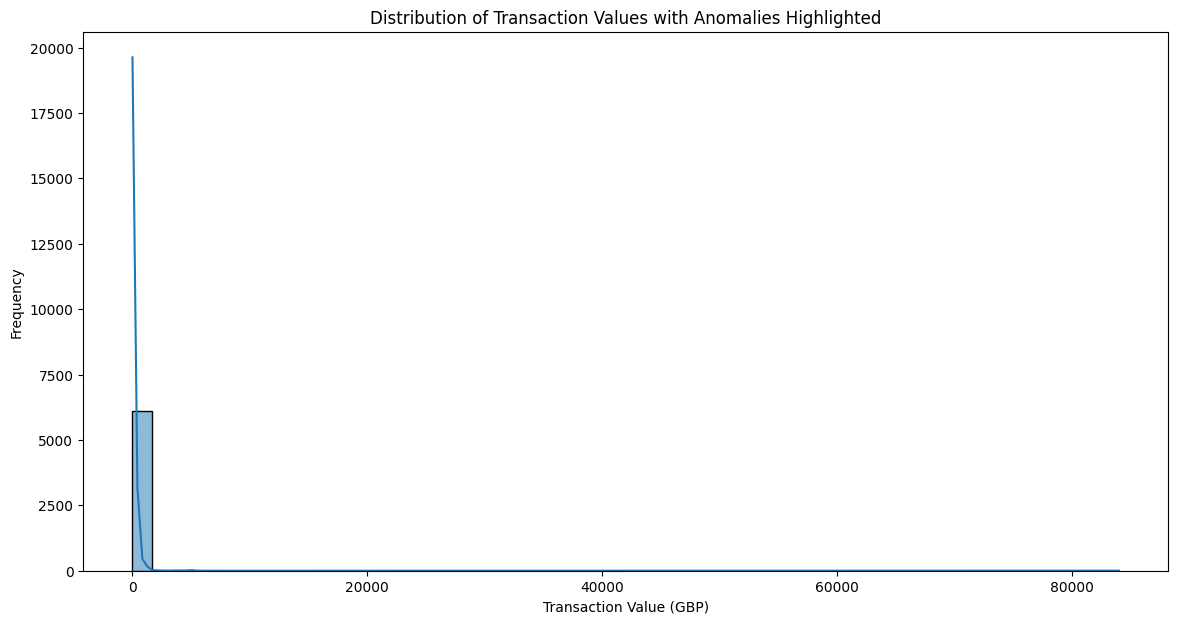

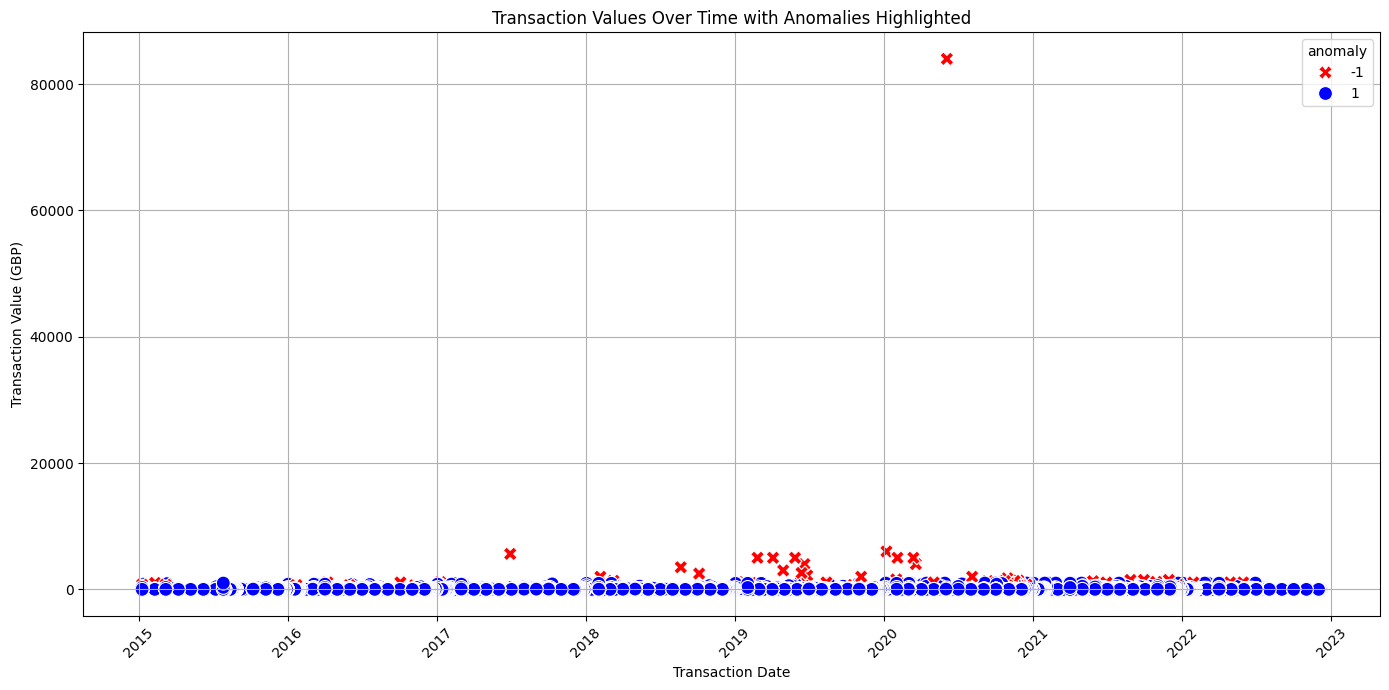

In [29]:
from sklearn.ensemble import IsolationForest

# Prepare data for anomaly detection
# We'll focus on 'Debit Amount (GBP)' for anomaly detection for now
# Consider transactions as individual data points

anomaly_df = df.copy()
anomaly_df['Transaction_Value'] = anomaly_df['Debit Amount (GBP)'].fillna(0) # Focus on debit amounts as spending anomalies

# Filter out zero transactions as they are not typically anomalies in spending
anomaly_df = anomaly_df[anomaly_df['Transaction_Value'] > 0]

# Select the feature for anomaly detection
X_anomaly = anomaly_df[['Transaction_Value']]

# Initialize and train Isolation Forest model
# contamination is the expected proportion of outliers in the data set.
# A higher value means more anomalies will be detected.
# We'll start with a small, reasonable value like 0.01 (1% anomalies).
model_if = IsolationForest(contamination=0.01, random_state=42)
model_if.fit(X_anomaly)

# Predict anomalies (-1 for outliers, 1 for inliers)
anomaly_df['anomaly'] = model_if.predict(X_anomaly)

# Add anomaly score to the DataFrame BEFORE filtering for anomalies
anomaly_df['anomaly_score'] = model_if.decision_function(X_anomaly)

# Filter for actual anomalies
anomalies = anomaly_df[anomaly_df['anomaly'] == -1]

print(f"Detected {len(anomalies)} anomalies (transactions flagged as unusual) based on 'Debit Amount (GBP)':\n")

# Display the top 10 most anomalous debit transactions
# Sorting by the 'anomaly score' (decision_function) can highlight the 'most' anomalous.
# Lower score means more anomalous.
print("Top 10 most anomalous debit transactions:")
display(anomalies.sort_values(by='anomaly_score').head(10)[['Transaction Date', 'Merchant Name', 'Transaction_Value', 'Category', 'anomaly_score']])

# Visualize anomalies
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.histplot(anomaly_df['Transaction_Value'], bins=50, kde=True)
plt.title('Distribution of Transaction Values with Anomalies Highlighted')
plt.xlabel('Transaction Value (GBP)')
plt.ylabel('Frequency')

# Highlight anomalies on the plot (optional: requires more advanced plotting for clear visibility on a histogram)
# For better visibility, a scatter plot might be more suitable for highlighting.

plt.figure(figsize=(14, 7))
sns.scatterplot(data=anomaly_df, x='Transaction Date', y='Transaction_Value', hue='anomaly', style='anomaly', palette={1: 'blue', -1: 'red'}, markers={1: 'o', -1: 'X'}, s=100)
plt.title('Transaction Values Over Time with Anomalies Highlighted')
plt.xlabel('Transaction Date')
plt.ylabel('Transaction Value (GBP)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interactive Visual Analytics: Animated Cashflow Maps

In [21]:
import plotly.express as px

# Prepare data for animated chart: melt the monthly_financials DataFrame
# We'll focus on expense categories for this animation
animation_df = monthly_financials[['YearMonth'] + expense_categories].copy()
animation_df_long = animation_df.melt(id_vars=['YearMonth'], var_name='Category', value_name='Spending Amount (GBP)')

# Sort by YearMonth to ensure correct animation order
animation_df_long = animation_df_long.sort_values(by='YearMonth')

# Create the animated bar chart
fig = px.bar(
    animation_df_long,
    x='Category',
    y='Spending Amount (GBP)',
    animation_frame='YearMonth',
    color='Category',
    title='Monthly Spending by Category Over Time',
    labels={'Spending Amount (GBP)': 'Spending Amount (GBP)', 'Category': 'Spending Category'},
    height=600
)

# Update layout for better aesthetics
fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Monthly Spending (GBP)',
    showlegend=False, # Legend can get cluttered in animation
    title_x=0.5
)

# Ensure the animation plays smoothly
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 500

fig.show()

In [37]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Ensure 'YearMonth' is a datetime object for Plotly compatibility
# This line is added to explicitly convert to datetime in case it was a PeriodDtype upstream
if isinstance(monthly_financials['YearMonth'].dtype, pd.PeriodDtype):
    monthly_financials['YearMonth'] = monthly_financials['YearMonth'].dt.to_timestamp()
elif not pd.api.types.is_datetime64_any_dtype(monthly_financials['YearMonth']):
    monthly_financials['YearMonth'] = pd.to_datetime(monthly_financials['YearMonth'])

# Prepare data for plotting (excluding non-expense categories from spending sum for a clearer view)
expense_categories = [col for col in monthly_financials.columns if col not in ['YearMonth', 'Monthly Income'] and col not in ['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax']]
monthly_financials['Total Monthly Spending'] = monthly_financials[expense_categories].sum(axis=1)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces for individual category spending (bars)
for category in expense_categories:
    fig.add_trace(
        go.Bar(
            x=monthly_financials['YearMonth'],
            y=monthly_financials[category],
            name=category,
            hovertemplate='<b>%{x|%Y-%m}</b><br>' + category + ': £%{y:.2f}<extra></extra>'
        ),
        secondary_y=False,
    )

# Add trace for total monthly income (line)
fig.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Monthly Income'],
        name='Monthly Income',
        mode='lines+markers',
        line=dict(color='green', width=3),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Monthly Income: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)

# Add trace for total monthly spending (line) for trend comparison
fig.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Total Monthly Spending'],
        name='Total Monthly Spending',
        mode='lines+markers',
        line=dict(color='red', width=3, dash='dash'),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Total Monthly Spending: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)

# Update layout
fig.update_layout(
    title_text="Monthly Categorical Spending vs. Income and Total Spending Trends",
    title_x=0.5,
    barmode='stack',
    hovermode="x unified",
    xaxis_title="Date",
    yaxis_title="Monthly Spending (GBP)",
    legend_title="Category",
    height=600
)
fig.update_yaxes(title_text="Monthly Income / Total Spending (GBP)", secondary_y=True)

fig.show()

## 4. Advanced Colab Integration: Instant HTML Reports

In [40]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from google.colab import files
import numpy as np
from plotly.subplots import make_subplots

print("Generating HTML Dashboard...")

# --- Re-execute necessary data preparation steps for reproducibility ---

# Standardize categories (re-running this to ensure consistency)
def standardize_category(category):
    category = str(category).lower().strip()
    if 'grocer' in category or 'supermarket' in category:
        return 'Groceries'
    elif 'travel' in category or 'transport' in category or 'bus' in category or 'train' in category or 'flight' in category:
        return 'Travel & Transport'
    elif 'utilit' in category or 'electric' in category or 'water' in category or 'gas' in category or 'internet' in category:
        return 'Utilities'
    elif 'eat' in category or 'restaurant' in category or 'cafe' in category or 'food' in category:
        return 'Dining Out'
    elif 'shop' in category or 'retail' in category:
        return 'Shopping'
    elif 'health' in category or 'medical' in category or 'pharmacy' in category:
        return 'Health & Medical'
    elif 'salary' in category or 'income' in category or 'pay' in category:
        return 'Income'
    elif 'rent' in category or 'mortgage' in category:
        return 'Housing'
    elif 'entert' in category or 'movie' in category or 'music' in category or 'game' in category:
        return 'Entertainment'
    elif 'education' in category or 'course' in category or 'school' in category:
        return 'Education'
    elif 'fee' in category or 'charge' in category or 'other' in category or category == '':
        return 'Miscellaneous'
    else:
        return category.capitalize()

# Re-apply category standardization (assuming df is already loaded and 'Category' is filled)
df['Category'] = df['Category'].apply(standardize_category)

# Re-extract merchant names (assuming df is already loaded and 'Transaction Description' is filled)
import re
def extract_merchant_name(description):
    description = str(description).upper()
    patterns = {
        r'AMZNMKTPLACE|AMZN MKTP|AMAZON': 'Amazon',
        r'LIDL GB': 'Lidl',
        r'MARKS&SPENCER PLC|M&S': 'Marks & Spencer',
        r'TRAINAWAY APS': 'Trainaway',
        r'TRAVELIUM LLC': 'Travelium',
        r'ALADDINS BIKES': 'Aladdins Bikes',
        r'Q WANG': 'Q Wang',
        r'UBER\s+\*?TRIP|UBER EATS': 'Uber',
        r'EXPEDIA': 'Expedia',
        r'SEVERN TRENT WATER': 'Severn Trent Water',
        r'GOOD ENERGY LTD': 'Good Energy',
        r'HEAVENLY DESSERTS': 'Heavenly Desserts',
        r'RLR-CC\.COM': 'RLR-CC',
        r'TESCO': 'Tesco',
        r'SAINSBURYS': 'Sainsbury\'s',
        r'ASDA': 'Asda',
        r'PAYPAL': 'PayPal',
        r'GOOGLE': 'Google',
        r'APPLE': 'Apple',
        r'SPOTIFY': 'Spotify',
        r'NETFLIX': 'Netflix',
        r'CO-OP': 'Co-op',
        r'STARBUCKS': 'Starbucks',
        r'COSTA': 'Costa',
        r'SPORTSDIRECT': 'Sports Direct',
        r'CORGI HOMEPLAN': 'Corgi HomePlan',
        r'ARRIVA TRAINS': 'Arriva Trains',
        r'B&Q': 'B&Q',
        r'PRIMARK': 'Primark',
        r'HMV': 'HMV',
        r'NATWEST': 'NatWest',
        r'LLOYDS BANK': 'Lloyds Bank',
        r'BARCLAYS': 'Barclays',
        r'HALIFAX': 'Halifax'
    }

    for pattern, merchant_name in patterns.items():
        if re.search(pattern, description):
            return merchant_name

    if 'SAVE THE CHANGE' in description:
        return 'Savings Transfer'
    if 'NON-GBP' in description:
        return 'Foreign Transaction Fee'
    if 'ACCOUNT FEE' in description or 'BANK CHARGE' in description:
        return 'Bank Fees'
    if 'CC SWANSEA C.TAX' in description or 'COUNCIL TAX' in description:
        return 'Council Tax'
    if 'ANDREW MUMBI' in description or 'PAULINA PIPPEN' in description or re.search(r'P2P|PERSON TO PERSON', description):
        return 'Personal Transfer'

    match = re.search(r'^([A-Z][A-Z0-9\s&\.-]+?)(?:\s+GB|\s+LLC|\s+APS|\s+PLC|\s+LTD|\s+CO|\s+INC|\s+CORP|\s+STORE|\s+SUPERMARKET|\s+CAFE|\s+REST|\s+PUB|\s+GRAB|\s+EBAY|\s+PRIME|\s+SUBSCRIPTION|\s+SERVICES|\s+ONLINE|\s+SHOP|\s+ECOM|\s+MARKET|\s+CITY|\s+UK|\s+US|\s+EU|\s+\d{2}/\d{2}|\s+\d{1,4})', description)
    if match:
        potential_merchant = match.group(1).strip()
        exclusion_list = [
            'TRANSFER', 'PAYMENT', 'INCOME', 'FEE', 'INTEREST', 'DEBIT', 'CREDIT', 'BILL',
            'CHARGE', 'TOP UP', 'REFUND', 'BANK', 'TRANSACTION', 'FX', 'WITHDRAWAL', 'DEPOSIT',
            'CARD', 'AUTH', 'PURCHASE', 'SALE', 'SERVICE', 'ADJUSTMENT', 'CASH'
        ]
        if len(potential_merchant) > 2 and not any(phrase in potential_merchant for phrase in exclusion_list):
            return ' '.join([word.capitalize() for word in potential_merchant.split()])
    return 'Unknown Merchant'

df['Merchant Name'] = df['Transaction Description'].apply(extract_merchant_name)

# Re-apply currency conversion
EXCHANGE_RATE_FOREIGN_TO_GBP = 0.8 # Define it again to be safe
df['Location Country'] = df['Location Country'].fillna('UK')
def convert_to_gbp(row):
    if row['Location Country'] != 'UK':
        if pd.notna(row['Debit Amount']):
            row['Debit Amount (GBP)'] = row['Debit Amount'] * EXCHANGE_RATE_FOREIGN_TO_GBP
        else:
            row['Debit Amount (GBP)'] = None
        if pd.notna(row['Credit Amount']):
            row['Credit Amount (GBP)'] = row['Credit Amount'] * EXCHANGE_RATE_FOREIGN_TO_GBP
        else:
            row['Credit Amount (GBP)'] = None
    else:
        row['Debit Amount (GBP)'] = row['Debit Amount']
        row['Credit Amount (GBP)'] = row['Credit Amount']
    return row
df = df.apply(convert_to_gbp, axis=1)

# Re-calculate monthly_transactions
df['YearMonth'] = df['Transaction Date'].dt.to_period('M')
monthly_transactions = df.groupby('YearMonth').agg(
    Monthly_Debit=('Debit Amount', 'sum'),
    Monthly_Credit=('Credit Amount', 'sum')
).fillna(0)
monthly_transactions['Monthly_Net_Flow'] = monthly_transactions['Monthly_Credit'] - monthly_transactions['Monthly_Debit']
monthly_transactions = monthly_transactions.reset_index()
monthly_transactions['YearMonth'] = monthly_transactions['YearMonth'].astype(str)

# Prepare data for Sunburst chart
category_merchant_spending = df.groupby(['Category', 'Merchant Name'])['Debit Amount (GBP)'].sum().reset_index()
category_merchant_spending = category_merchant_spending[~category_merchant_spending['Category'].isin(['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax'])]
category_merchant_spending.columns = ['Category', 'Subcategory', 'Amount']

sunburst_data_list = []
category_total_spending = category_merchant_spending.groupby('Category')['Amount'].sum().reset_index()
for index, row in category_total_spending.iterrows():
    sunburst_data_list.append({
        'ids': row['Category'],
        'labels': row['Category'],
        'parents': '',
        'values': row['Amount']
    })
for index, row in category_merchant_spending.iterrows():
    sunburst_data_list.append({
        'ids': f"{row['Category']}-{row['Subcategory']}",
        'labels': row['Subcategory'],
        'parents': row['Category'],
        'values': row['Amount']
    })
sunburst_df = pd.DataFrame(sunburst_data_list)

# Prepare data for Dual-Axis chart
monthly_category_spending = df.groupby(['YearMonth', 'Category'])['Debit Amount (GBP)'].sum().unstack(fill_value=0).reset_index()
monthly_income = df[df['Category'] == 'Income'].groupby('YearMonth')['Credit Amount (GBP)'].sum().reset_index()
monthly_income.rename(columns={'Credit Amount (GBP)': 'Monthly Income'}, inplace=True)
monthly_financials = pd.merge(monthly_category_spending, monthly_income, on='YearMonth', how='left').fillna(0)
# FIX: Convert PeriodDtype to Timestamp
monthly_financials['YearMonth'] = monthly_financials['YearMonth'].dt.to_timestamp()

# Prepare data for Budget Audit chart (using the same default targets as in the notebook)
needs_categories = [
    'Groceries', 'Housing', 'Utilities', 'Health & Medical',
    'Travel & Transport', 'Bills', 'Services'
]
wants_categories = [
    'Dining Out', 'Entertainment', 'Shopping', 'Amazon',
    'Fitness', 'Home improvement', 'Hotels', 'Dine out', 'Clothes'
]
savings_categories = [
    'Savings', 'Investment', 'Account transfer'
]

# monthly_transactions['YearMonth'] was converted to str earlier, so pd.to_datetime works fine here.
monthly_transactions['YearMonth'] = pd.to_datetime(monthly_transactions['YearMonth'])
if 'Monthly_Credit' in monthly_financials.columns:
    monthly_financials = monthly_financials.drop(columns=['Monthly_Credit'])
monthly_financials = pd.merge(monthly_financials, monthly_transactions[['YearMonth', 'Monthly_Credit']], on='YearMonth', how='left').fillna(0)
monthly_financials['Actual Monthly Income'] = monthly_financials.apply(
    lambda row: row['Monthly_Credit'] if row['Monthly Income'] == 0 else row['Monthly Income'],
    axis=1
)
monthly_financials['Actual Monthly Income'] = monthly_financials['Actual Monthly Income'].replace(np.nan, 0)
monthly_financials['Needs_Spending'] = monthly_financials[[
    col for col in needs_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Wants_Spending'] = monthly_financials[[
    col for col in wants_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Savings_Spending'] = monthly_financials[[
    col for col in savings_categories if col in monthly_financials.columns
]].sum(axis=1)
monthly_financials['Needs_%'] = (monthly_financials['Needs_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Wants_%'] = (monthly_financials['Wants_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials['Savings_%'] = (monthly_financials['Savings_Spending'] / monthly_financials['Actual Monthly Income'].replace(0, np.nan) * 100).fillna(0)
monthly_financials.replace([np.inf, -np.inf], 0, inplace=True)
average_income_months = monthly_financials[monthly_financials['Actual Monthly Income'] > 0]
audit_data = average_income_months[['YearMonth', 'Needs_%', 'Wants_%', 'Savings_%']].melt(id_vars='YearMonth', var_name='Category Type', value_name='Percentage of Income')
audit_data['Target'] = audit_data['Category Type'].map({'Needs_%': 50, 'Wants_%': 30, 'Savings_%': 20})

# Prepare data for Animated Cashflow Map
expense_categories_for_anim = [col for col in monthly_financials.columns if col not in ['YearMonth', 'Monthly Income'] and col not in ['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax']] # Exclude computed columns
animation_df = monthly_financials[['YearMonth'] + expense_categories_for_anim].copy()
animation_df_long = animation_df.melt(id_vars=['YearMonth'], var_name='Category', value_name='Spending Amount (GBP)')
animation_df_long = animation_df_long.sort_values(by='YearMonth')

# --- Generate and save each Plotly figure to HTML ---

# 1. Sunburst Chart
fig_sunburst = go.Figure(go.Sunburst(
    ids=sunburst_df['ids'],
    labels=sunburst_df['labels'],
    parents=sunburst_df['parents'],
    values=sunburst_df['values'],
    branchvalues="total",
    hovertemplate='<b>%{label}</b><br>Amount: £%{value:.2f}<extra></extra>'
))
fig_sunburst.update_layout(margin = dict(t=0, l=0, r=0, b=0),
                      title_text='Spending Categories Hierarchy (Sunburst Chart)',
                      title_x=0.5)
fig_sunburst.write_html('sunburst_chart.html', auto_open=False)

# 2. Dual-Axis Chart
expense_categories_dual_axis = [col for col in monthly_financials.columns if col not in ['YearMonth', 'Monthly Income'] and col not in ['Income', 'Savings Transfer', 'Foreign Transaction Fee', 'Bank Fees', 'Personal Transfer', 'Council Tax', 'Total Monthly Spending', 'Monthly_Credit', 'Actual Monthly Income', 'Needs_Spending', 'Wants_Spending', 'Savings_Spending', 'Needs_%', 'Wants_%', 'Savings_%']]
monthly_financials['Total Monthly Spending'] = monthly_financials[expense_categories_dual_axis].sum(axis=1)
fig_dual_axis = make_subplots(specs=[[{"secondary_y": True}]]) # Changed here
for category in expense_categories_dual_axis:
    fig_dual_axis.add_trace(
        go.Bar(
            x=monthly_financials['YearMonth'],
            y=monthly_financials[category],
            name=category,
            hovertemplate='<b>%{x|%Y-%m}</b><br>' + category + ': £%{y:.2f}<extra></extra>'
        ),
        secondary_y=False,
    )
fig_dual_axis.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Monthly Income'],
        name='Monthly Income',
        mode='lines+markers',
        line=dict(color='green', width=3),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Monthly Income: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)
fig_dual_axis.add_trace(
    go.Scatter(
        x=monthly_financials['YearMonth'],
        y=monthly_financials['Total Monthly Spending'],
        name='Total Monthly Spending',
        mode='lines+markers',
        line=dict(color='red', width=3, dash='dash'),
        hovertemplate='<b>%{x|%Y-%m}</b><br>Total Monthly Spending: £%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)
fig_dual_axis.update_layout(
    title_text="Monthly Categorical Spending vs. Income and Total Spending Trends",
    title_x=0.5,
    barmode='stack',
    hovermode="x unified",
    xaxis_title="Date",
    yaxis_title="Monthly Spending (GBP)",
    legend_title="Category",
    height=600
)
fig_dual_axis.update_yaxes(title_text="Monthly Income / Total Spending (GBP)", secondary_y=True)
fig_dual_axis.write_html('dual_axis_chart.html', auto_open=False)

# 3. Budget Audit Chart
fig_budget_audit = px.bar(
    audit_data,
    x='YearMonth',
    y='Percentage of Income',
    color='Category Type',
    title='Monthly 50/30/20 Budget Rule Adherence',
    labels={'Percentage of Income': 'Percentage of Income', 'YearMonth': 'Month'},
    hover_data={'Target': ':.0f'}
)
fig_budget_audit.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[50]*len(audit_data['YearMonth'].unique()), mode='lines', name='Needs Target (50%)', line=dict(color='red', dash='dash')))
fig_budget_audit.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[30]*len(audit_data['YearMonth'].unique()), mode='lines', name='Wants Target (30%)', line=dict(color='orange', dash='dash')))
fig_budget_audit.add_trace(go.Scatter(x=audit_data['YearMonth'].unique(), y=[20]*len(audit_data['YearMonth'].unique()), mode='lines', name='Savings Target (20%)', line=dict(color='green', dash='dash')))
fig_budget_audit.update_layout(barmode='relative', yaxis_range=[0, 100])
fig_budget_audit.write_html('budget_audit_chart.html', auto_open=False)

# 4. Animated Cashflow Map
fig_animated_cashflow = px.bar(
    animation_df_long,
    x='Category',
    y='Spending Amount (GBP)',
    animation_frame='YearMonth',
    color='Category',
    title='Monthly Spending by Category Over Time',
    labels={'Spending Amount (GBP)': 'Spending Amount (GBP)', 'Category': 'Spending Category'},
    height=600
)
fig_animated_cashflow.update_layout(
    xaxis_title='Category',
    yaxis_title='Monthly Spending (GBP)',
    showlegend=False,
    title_x=0.5
)
fig_animated_cashflow.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig_animated_cashflow.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 500
fig_animated_cashflow.write_html('animated_cashflow_map.html', auto_open=False)

# --- Create a main HTML dashboard file ---
dashboard_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Financial Dashboard</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; }
        h1 { color: #333; text-align: center; }
        .chart-container { margin-bottom: 50px; border: 1px solid #eee; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
        iframe { width: 100%; height: 600px; border: none; }
    </style>
</head>
<body>
    <h1>Personal Financial Dashboard</h1>

    <div class="chart-container">
        <h2>Spending Categories Hierarchy</h2>
        <iframe src="sunburst_chart.html"></iframe>
    </div>

    <div class="chart-container">
        <h2>Monthly Categorical Spending vs. Income and Total Spending Trends</h2>
        <iframe src="dual_axis_chart.html"></iframe>
    </div>

    <div class="chart-container">
        <h2>Monthly 50/30/20 Budget Rule Adherence</h2>
        <iframe src="budget_audit_chart.html"></iframe>
    </div>

    <div class="chart-container">
        <h2>Monthly Spending by Category Over Time (Animated)</h2>
        <iframe src="animated_cashflow_map.html"></iframe>
    </div>

</body>
</html>
"""

with open('financial_dashboard.html', 'w') as f:
    f.write(dashboard_html)

# --- Provide download link ---
files.download('financial_dashboard.html')
files.download('sunburst_chart.html')
files.download('dual_axis_chart.html')
files.download('budget_audit_chart.html')
files.download('animated_cashflow_map.html')

print("Dashboard generation complete! Check your downloads for 'financial_dashboard.html' and individual chart files.")

Generating HTML Dashboard...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dashboard generation complete! Check your downloads for 'financial_dashboard.html' and individual chart files.
